In [1]:
import astropy.io.fits as pf
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import os
import subprocess
import importlib as imp
import copy
import scipy.stats
from matplotlib.pyplot import cm
from scipy.stats import kde
import figure_subroutines as subs
from astropy import units as u
from astropy.coordinates import SkyCoord
from pylab import *
from matplotlib import ticker

In [2]:
fieldnames = ["ej0","ej1","ej2","ej3","ej4","ej5","ej6","ej7","ej8","ek0","ek1","ek2","ek3",
              "ek5","ek6","ek7","ek8","el0","el1","el2"]

#,"el3","el5","el6","o5","o6","o8","o6s",
#              "o9s","p0","p1","p3","p4","p5","p6","p8","p9","q0","q1","q3","q4","q5","q6","q8",
#"q9","r0","r1","r3","r4","r5","r6","r7","r8","r9"]

numname = np.size(fieldnames)

fieldandband = []

for i in range(0,numname):
    fieldandband.append(fieldnames[i]+'_aq')
    fieldandband.append(fieldnames[i]+'_au')
    fieldandband.append(fieldnames[i]+'_bq')
    fieldandband.append(fieldnames[i]+'_bu')
    fieldandband.append(fieldnames[i]+'_cq')
    fieldandband.append(fieldnames[i]+'_cu')
    fieldandband.append(fieldnames[i]+'_dq')
    fieldandband.append(fieldnames[i]+'_du')

print(fieldandband)

numfields = np.size(fieldandband)
print(numfields)

['ej0_aq', 'ej0_au', 'ej0_bq', 'ej0_bu', 'ej0_cq', 'ej0_cu', 'ej0_dq', 'ej0_du', 'ej1_aq', 'ej1_au', 'ej1_bq', 'ej1_bu', 'ej1_cq', 'ej1_cu', 'ej1_dq', 'ej1_du', 'ej2_aq', 'ej2_au', 'ej2_bq', 'ej2_bu', 'ej2_cq', 'ej2_cu', 'ej2_dq', 'ej2_du', 'ej3_aq', 'ej3_au', 'ej3_bq', 'ej3_bu', 'ej3_cq', 'ej3_cu', 'ej3_dq', 'ej3_du', 'ej4_aq', 'ej4_au', 'ej4_bq', 'ej4_bu', 'ej4_cq', 'ej4_cu', 'ej4_dq', 'ej4_du', 'ej5_aq', 'ej5_au', 'ej5_bq', 'ej5_bu', 'ej5_cq', 'ej5_cu', 'ej5_dq', 'ej5_du', 'ej6_aq', 'ej6_au', 'ej6_bq', 'ej6_bu', 'ej6_cq', 'ej6_cu', 'ej6_dq', 'ej6_du', 'ej7_aq', 'ej7_au', 'ej7_bq', 'ej7_bu', 'ej7_cq', 'ej7_cu', 'ej7_dq', 'ej7_du', 'ej8_aq', 'ej8_au', 'ej8_bq', 'ej8_bu', 'ej8_cq', 'ej8_cu', 'ej8_dq', 'ej8_du', 'ek0_aq', 'ek0_au', 'ek0_bq', 'ek0_bu', 'ek0_cq', 'ek0_cu', 'ek0_dq', 'ek0_du', 'ek1_aq', 'ek1_au', 'ek1_bq', 'ek1_bu', 'ek1_cq', 'ek1_cu', 'ek1_dq', 'ek1_du', 'ek2_aq', 'ek2_au', 'ek2_bq', 'ek2_bu', 'ek2_cq', 'ek2_cu', 'ek2_dq', 'ek2_du', 'ek3_aq', 'ek3_au', 'ek3_bq', 'ek3_bu',

In [3]:
C_initial_files = []
C_feather_files = []
G_initial_files = []
G_matched_files = []
G_feather_files = []
Gu_files = []
Gv_files = []
Cu_files = []
Cv_files = []
uv_delt = np.zeros([numfields])

for i in range(0,numfields):
    
    step_files = ['../../GMIMS_CGPS_OB_RW/THESIS_pics/G_initial_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/G_matched_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/G_feather_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/C_initial_uv_'+fieldandband[i]+'.fits',
                  '../../GMIMS_CGPS_OB_RW/THESIS_pics/C_feather_uv_'+fieldandband[i]+'.fits']
    
    field = fits.open(step_files[3])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    C_initial_files.append(data)
    del field
    
    field = fits.open(step_files[4])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    C_feather_files.append(data)
    del field

    u,v = subs.make_axis_lists_2D(hdr)
    Cu_files.append(u)
    Cv_files.append(v)
    
    field = fits.open(step_files[0])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_initial_files.append(data)
    del field
    
    field = fits.open(step_files[1])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_matched_files.append(data)
    del field
    
    field = fits.open(step_files[2])
    hdr = field[0].header
    data = field[0].data[0,0,:,:]
    G_feather_files.append(data)
    del field
    
    u,v = subs.make_axis_lists_2D(hdr)
    Gu_files.append(u)
    Gv_files.append(v)
    
    uv_delt[i] = hdr['CDELT2']
    print(i,fieldandband[i],uv_delt[i])
    

(0, 'ej0_aq', 4.2913556)
(1, 'ej0_au', 4.2913556)
(2, 'ej0_bq', 4.2704163)
(3, 'ej0_bu', 4.2704163)
(4, 'ej0_cq', 4.2297368)
(5, 'ej0_cu', 4.2297368)
(6, 'ej0_dq', 4.209393)
(7, 'ej0_du', 4.209393)
(8, 'ej1_aq', 4.2913556)
(9, 'ej1_au', 4.2913556)
(10, 'ej1_bq', 4.2704163)
(11, 'ej1_bu', 4.2704163)
(12, 'ej1_cq', 4.2297368)
(13, 'ej1_cu', 4.2297368)
(14, 'ej1_dq', 4.209393)
(15, 'ej1_du', 4.209393)
(16, 'ej2_aq', 4.2913556)
(17, 'ej2_au', 4.2913556)
(18, 'ej2_bq', 4.2704163)
(19, 'ej2_bu', 4.2704163)
(20, 'ej2_cq', 4.2297368)
(21, 'ej2_cu', 4.2297368)
(22, 'ej2_dq', 4.209393)
(23, 'ej2_du', 4.209393)
(24, 'ej3_aq', 4.2913556)
(25, 'ej3_au', 4.2913556)
(26, 'ej3_bq', 4.2704163)
(27, 'ej3_bu', 4.2704163)
(28, 'ej3_cq', 4.2297368)
(29, 'ej3_cu', 4.2297368)
(30, 'ej3_dq', 4.209393)
(31, 'ej3_du', 4.209393)
(32, 'ej4_aq', 4.2913556)
(33, 'ej4_au', 4.2913556)
(34, 'ej4_bq', 4.2704163)
(35, 'ej4_bu', 4.2704163)
(36, 'ej4_cq', 4.2297368)
(37, 'ej4_cu', 4.2297368)
(38, 'ej4_dq', 4.209393)
(39, 

In [5]:
ampl_G_initial = []
ampl_G_match = []
ampl_G_feath = []
ampl_C_initial = []
ampl_C_feath = []

radius_G_fields = []
radius_C_fields = []

for k in range(0,numfields):

    #=============== SA initial ======================================
    ampl_G_initial.append(G_initial_files[k][1:512,0:257])
    #print(ampl_G_initial[i][0,0])
    #print(ampl_G_initial[i][511,0])
    #print(ampl_G_initial[i][1022,0])
    #print(ampl_G_initial[i].shape)
    #print('')
    #=============== SA matched ======================================
    ampl_G_match.append(G_matched_files[k][1:512,0:257])
    #print(ampl_G_match[i][0,0])
    #print(ampl_G_match[i][511,0])
    #print(ampl_G_match[i][1022,0])
    #print(ampl_G_match[i].shape)
    #print('')
    #=============== SA feathered ======================================
    ampl_G_feath.append(G_feather_files[k][1:512,0:257])
    #print(ampl_G_feath[i][0,0])
    #print(ampl_G_feath[i][511,0])
    #print(ampl_G_feath[i][1022,0])
    #print(ampl_G_feath[i].shape)
    #print('')
    #=============== ST initial ======================================
    ampl_C_initial.append(C_initial_files[k][1:512,0:257])
    #print(ampl_C_initial[i][0,0])
    #print(ampl_C_initial[i][511,0])
    #print(ampl_C_initial[i][1022,0])
    #print(ampl_C_initial[i].shape)
    #print('')
    #=============== ST feathered ======================================
    ampl_C_feath.append(C_feather_files[k][1:512,0:257])
    #print(ampl_C_feath[i][0,0])
    #print(ampl_C_feath[i][511,0])
    #print(ampl_C_feath[i][1022,0])
    #print(ampl_C_feath[i].shape)
    #print('')

    radius_C = np.zeros([511,257])
    radius_G = np.zeros([511,257])
    
    u_G = np.flip(Gu_files[k][1:258],axis=0)
    v_G = Gv_files[k][1:512]
    u_C = np.flip(Cu_files[k][1:258],axis=0)
    v_C = Cv_files[k][1:512]
    print(k)
    #print(np.min(u_C), np.max(u_C), u_C.shape)
    #print(np.min(v_C), np.max(v_C), v_C.shape)
    #print(np.min(u_G), np.max(u_G), u_G.shape)
    #print(np.min(v_G), np.max(v_G), v_G.shape)
    #print('')
    
    for i in range(0,257):
        for j in range(0,511):
            radius_G[j,i] = np.sqrt((u_G[i])**2+(v_G[j])**2)
            radius_C[j,i] = np.sqrt((u_C[i])**2+(v_C[j])**2)
    
    radius_C_fields.append(radius_C)
    radius_G_fields.append(radius_G)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


In [6]:
SA_orig_samples = np.zeros([numfields,50])
SA_match_samples = np.zeros([numfields,50])
SA_feath_samples = np.zeros([numfields,50])
ST_orig_samples = np.zeros([numfields,50])
ST_feath_samples = np.zeros([numfields,50])
rad_samples = np.zeros([numfields,50])

for j in range(0,numfields):
    print(j)
    rad_samples[j,:] = np.unique(radius_C_fields[j])[0:50]
    for i in range(0,50):
        wx = np.where((radius_C_fields[j]==rad_samples[j,i]))[1]
        wy = np.where((radius_C_fields[j]==rad_samples[j,i]))[0]
        SA_orig_samples[j,i] = np.mean(ampl_G_initial[j][wy,wx])
        SA_match_samples[j,i] = np.mean(ampl_G_match[j][wy,wx])
        SA_feath_samples[j,i] = np.mean(ampl_G_feath[j][wy,wx])
        ST_orig_samples[j,i] = np.mean(ampl_C_initial[j][wy,wx])
        ST_feath_samples[j,i] = np.mean(ampl_C_feath[j][wy,wx])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159


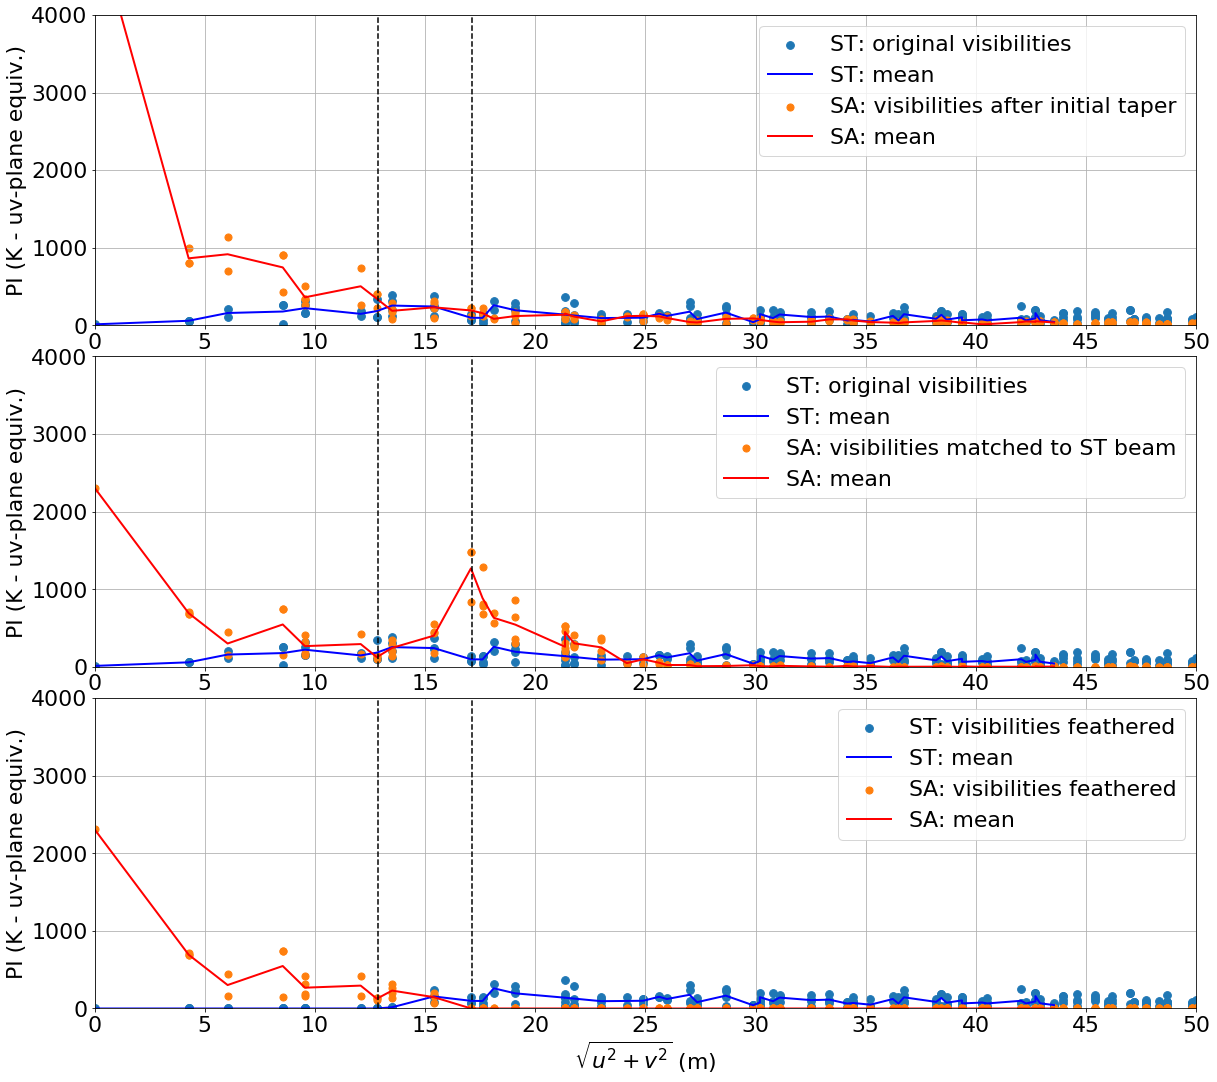

In [6]:
j = 35 # pick which field to plot

fs=22
lw = 2

axs = ['ax1','ax2','ax3']

fig = plt.figure(figsize=(17,15))
plt.subplots_adjust(top = 0.98, bottom = 0.06, right = 0.98, left = 0.08, hspace=0.1)

axs[0] = fig.add_subplot(311)
axs[0].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[0].scatter(radius_G_fields[j],ampl_G_initial[j],s=50,label='SA: visibilities after initial taper')
axs[0].plot(rad_samples[j,:],ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[0].plot(rad_samples[j,:],SA_orig_samples[j],color='red',linewidth=lw,label='SA: mean')
handles,labels = axs[0].get_legend_handles_labels()
order = [2,0,3,1]
axs[0].set_ylim(0,4000)
axs[0].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[1] = fig.add_subplot(312)
axs[1].scatter(radius_C_fields[j],ampl_C_initial[j],s=60,label='ST: original visibilities')
axs[1].scatter(radius_G_fields[j],ampl_G_match[j],s=50,label='SA: visibilities matched to ST beam')
axs[1].plot(rad_samples[j,:],ST_orig_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[1].plot(rad_samples[j,:],SA_match_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[1].set_ylim(0,4000)
handles,labels = axs[1].get_legend_handles_labels()
order = [2,0,3,1]
axs[1].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

axs[2] = fig.add_subplot(313)
axs[2].set_xlabel('$\sqrt{u^2+v^2}$ (m)',fontsize=fs)
axs[2].scatter(radius_C_fields[j],ampl_C_feath[j],s=60,label='ST: visibilities feathered')
axs[2].scatter(radius_G_fields[j],ampl_G_feath[j],s=50,label='SA: visibilities feathered')
axs[2].plot(rad_samples[j,:],ST_feath_samples[j],color='blue',linewidth=lw,label='ST: mean')
axs[2].plot(rad_samples[j,:],SA_feath_samples[j],color='red',linewidth=lw,label='SA: mean')
axs[2].set_ylim(0,4000)
handles,labels = axs[2].get_legend_handles_labels()
order = [2,0,3,1]
axs[2].legend([handles[idx] for idx in order], [labels[idx] for idx in order],fontsize=fs)

for i in range(0,3):
    axs[i].tick_params(axis="x", labelsize=fs)
    axs[i].tick_params(axis="y", labelsize=fs)
    axs[i].set_xlim(0,50)
    axs[i].set_ylabel('PI (K - uv-plane equiv.)',fontsize=fs)
    axs[i].plot([12.858,12.858],[0,80000],color='black',linestyle='dashed')
    axs[i].plot([17.144,17.144,],[0,80000],color='black',linestyle='dashed')
    axs[i].grid()
    axs[i].set_xticks([0,5,10,15,20,25,30,35,40,45,50])
    #axs[i].set_ticklabels(fontsize=fs)

In [8]:
ratioavg = np.zeros([numfields])

for j in range(0,numfields):
    
    woverlap = np.where((rad_samples[j,:]<16.8) & (rad_samples[j,:]>13.2))
    C_test = ST_orig_samples[j][woverlap]
    G_test = SA_match_samples[j][woverlap]
    #print(C_test)
    #print(G_test)
    avrg = (G_test+C_test)/2.
    #print(avrg)
    ratio = G_test/C_test
    ratioavg[j] = np.mean(ratio)
    #print(j,fieldandband[j],ratio,ratioavg[j])
    print(ratioavg[j])

1.3408246303114275
0.9328793087892592
1.405008960424927
0.9612323228375923
1.4846674438009537
0.9897417820774778
1.929666652656895
0.7354180280290757
2.3422699221431555
2.235014117186428
1.3735547969170145
1.6991817544340884
2.30253855772129
2.3376054411033658
1.6020871955364766
1.6795999971284914
1.1745698756652854
1.2305400988768906
1.704327029577395
1.1572405089805367
1.3522617663237577
1.0188692039644236
1.8483134131772405
0.9542773606998809
1.2782237862207864
1.1232522831187848
1.9109185064363938
0.8224133152306323
1.9121208122066782
0.7238575124591325
1.72321019030618
0.5836931845724487
2.5924691524027463
0.9281386287358706
2.100953228885369
1.3095310970986942
1.9745452070100424
1.319260688941272
1.256081459214475
0.8586148132657081
0.8748038982990878
1.5601167445985025
1.4728361687121057
1.617106834584605
2.1959103026358964
1.7175233906402445
1.1281917393523364
0.9000036740389303
1.4380740103040757
1.2092150863012086
1.0846959099437377
0.9022260872315614
0.9244807775243726
0.841

(array([ 7., 22., 31., 22., 29., 17., 15.,  6.,  3.,  1.,  4.,  1.,  0.,
         1.,  1.]),
 array([0.47963381, 0.72091837, 0.96220294, 1.20348751, 1.44477207,
        1.68605664, 1.9273412 , 2.16862577, 2.40991033, 2.6511949 ,
        2.89247946, 3.13376403, 3.3750486 , 3.61633316, 3.85761773,
        4.09890229]),
 <a list of 15 Patch objects>)

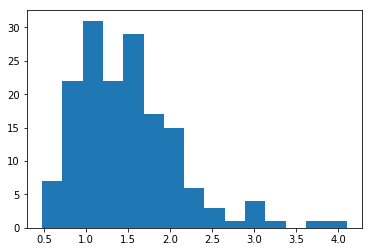

In [66]:
plt.hist(ratioavg, bins=15)  